## Exercises large classes (Week_02)

## Python libraries and settings

In [30]:
# Python libraries
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# Settings
import warnings
warnings.filterwarnings("ignore")

# Get working directory
print(os.getcwd())


/workspaces/data_analytics/WTYK/LC_02


### BigmacPrice.csv

In [31]:
# Read BigmacPrice.csv to data frame
df = pd.read_csv('BigmacPrice.csv', sep=',',encoding='utf-8')



# Print header
print (df.head(10))

# Show data types
print(df.dtypes)

# Show type of 'df'
print(type(df))



         date currency_code            name  local_price  dollar_ex  \
0  2000-04-01           ARS       Argentina         2.50          1   
1  2000-04-01           AUD       Australia         2.59          1   
2  2000-04-01           BRL          Brazil         2.95          1   
3  2000-04-01           GBP         Britain         1.90          1   
4  2000-04-01           CAD          Canada         2.85          1   
5  2000-04-01           CLP           Chile      1260.00        514   
6  2000-04-01           CNY           China         9.90          8   
7  2000-04-01           CZK  Czech Republic        54.37         39   
8  2000-04-01           DKK         Denmark        24.75          8   
9  2000-04-01           EUR       Euro area         2.56          1   

   dollar_price  
0          2.50  
1          2.59  
2          2.95  
3          1.90  
4          2.85  
5          2.45  
6          1.24  
7          1.39  
8          3.09  
9          2.56  
date              ob

### ChickenData.xlsx

In [32]:
# Read ChickenData.xlsx to data frame
df = pd.read_excel('ChickenData.xlsx', sheet_name='Sheet1')

# Print header
print (df.head(10))


# Show data types
print('\n', df.dtypes)




# Show type of 'df'
print('n\,type(df)')


# Create dictionary from the data frame with breed (keys) and eggs_per_year (values)
breed_eggs = dict(zip(df['breed'], df['eggs_per_year']))




# Print the dictionary
print(breed_eggs)




   chicken_id       weight              breed  eggs_per_year
0           1  2728.854920  New Hampshire Red            158
1           2  2323.761365         Australorp            273
2           3  2635.062034  New Hampshire Red            153
3           4  2603.985152      Plymouth Rock            268
4           5  3079.394487         Australorp            360
5           6  2250.163583        Barnevelder            317
6           7  2648.364847      Plymouth Rock            158
7           8  2371.107826  New Hampshire Red            275
8           9  2224.379423        Barnevelder            169
9          10  2577.250189      Plymouth Rock            340

 chicken_id         int64
weight           float64
breed             object
eggs_per_year      int64
dtype: object
n\,type(df)
{'New Hampshire Red': 297, 'Australorp': 213, 'Plymouth Rock': 314, 'Barnevelder': 316, 'ISA Brown': 225}


### Cars_autoscout24.csv

In [33]:
# Linux commands to get/set encoding of file (run in terminal)
# file -i Cars_autoscout24.csv
# --> provides 'charset=unknown-8bit'
# --> download the file and open with e.g. Notepad++ (on Windows)
# --> shows ANSI which is "windows-1252" (see https://de.wikipedia.org/wiki/Windows-1252)

# Convert to UTF-8, if needed, otherwise, use encoding='cp1252' in pd.read_csv
# iconv -f "windows-1252" -t "UTF-8" Cars_autoscout24.csv -o Cars_autoscout24_utf8.csv

# Read Cars_autoscout24.csv to data frame
df = pd.read_csv('Cars_autoscout24.csv', sep=';',encoding='cp1252')



# Function to extract numerical values from the column 'Price'
def extract_number(text):
    # Regular expression to extract numerical values
    number = re.findall(r'\d+', text)
    # Check if number is not empty
    if number:
        # Return the first element of the list
        return number[0]
    else:
        # Return None
        return None



# Apply the function to the column 'Price' and create a new column 'Price_numeric'
df['Price_numeric'] = df['Price'].apply(extract_number)

# Display the DataFrame
df.head(10)




,Offer_Id,Type,Price,PS,Init_Regist,Kilometer,Fuel_Type,Transmission,Price_numeric
0,7324420,AUDI A5 Sportback 3.0 TDI quattro S-tronic (Li...,CHF 22'500.–,245 PS,10.2014,75'000 km,Diesel,Automatisiertes Schaltgetriebe,22
1,7512768,MERCEDES-BENZ SLK 200 7G-Tronic (Cabriolet),CHF 23'749.–,184 PS,6.2013,46'655 km,Benzin,Automat sequentiell,23
2,7512034,MERCEDES-BENZ C 350 Avantgarde 4Matic 7G-Troni...,CHF 18'500.–,306 PS,6.2011,138'955 km,Benzin,Automat sequentiell,18
3,7512728,MERCEDES-BENZ A 45 AMG 4Matic Speedshift 7G-DC...,CHF 36'000.–,360 PS,8.2015,43'000 km,Benzin,Automatisiertes Schaltgetriebe,36
4,7490242,AUDI A5 Sportback 2.0 TFSI Sport quattro S-tro...,CHF 48'500.–,252 PS,9.2018,43'300 km,Benzin,Automatisiertes Schaltgetriebe,48
5,7512188,MERCEDES-BENZ SLK 200 Kompressor (Cabriolet),CHF 12'000.–,163 PS,12.2004,109'000 km,Benzin,Schaltgetriebe manuell,12
6,7512184,MERCEDES-BENZ C 350 Elégance Sport Edition 4Ma...,CHF 8'000.–,272 PS,5.2006,156'000 km,Benzin,Automat,8
7,7512142,SEAT Ibiza SC 1.4 TSI Cupra DSG (Kleinwagen),CHF 10'500.–,180 PS,2.201,71'400 km,Benzin,Automatisiertes Schaltgetriebe,10
8,7511265,PORSCHE 911 Turbo Cabrio PDK (Cabriolet),CHF 143'500.–,521 PS,7.2015,18'000 km,Benzin,Automatisiertes Schaltgetriebe,143
9,7511230,VW Golf 1.4 TSI Comfortline (Limousine),CHF 19'800.–,125 PS,12.2015,110'000 km,Benzin,Schaltgetriebe manuell,19


### Histogram of car prices

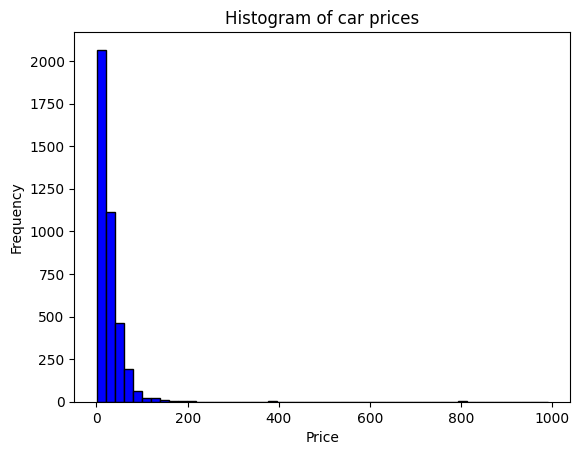

In [34]:
# Plotting the histogram of car prices
df['Price_numeric'] = df['Price_numeric'].astype(float)
plt.hist(df['Price_numeric'], bins=50, color='blue', edgecolor='black')
plt.title('Histogram of car prices')
plt.xlabel('Price')
plt.ylabel('Frequency') 
plt.show()


